# **Análisis del dataset elegido por el Grupo A**

## **Clasificación de Variables del Dataset**

### **Año/Anio**
#### Aunque el paso del tiempo es un fenómeno continuo en la realidad física, dentro de nuestro dataset la variable representa una agrupación temporal en intervalos enteros. Toma valores finitos, específicos y contables dentro de un rango definido (desde el año 2000 hasta el 2012). No admite valores intermedios o fraccionarios en el registro (por ejemplo, no existe el año 2005.4), lo que la clasifica como una variable discreta.

### **Id**
#### Dentro de los datasets, la variable Id se identifica como una variable cuantitativa, dado que esta se usa modo de conteo para representar y separar distintos registros de datos dentro de los datasets. A cada registro se le asigna un número (1,2,3), sin valores intermedios (1.2;1.5), por lo que podemos clasificarla como una variable cuantitativa discreta.

### **Mes**
#### Es de tipo cuantitativa discreta por que esta representada con numeros del 1 al 12, dado que un año no puede tomar más valores, 12.5 o 2.3. Los datasets trabajan con esta variable con el proposito de dar una mejor visibilidad del rango de tiempo en el cual ocurrieron ciertos accidentes y las causas detras de ellos.

### **Causas**
#### La variable causas es un tipo de variable cualitativa nominal porque utiliza palabras para identificar cada motivo de accidente, registradas en el dataset de tal manera que no permite considerarlas como variables cuantitativas que puedan tomar algun valor.

### **Numero**
#### Esta variable es cuantitativa discreta, pues representa el número de un mismo suceso ocurrido en un periodo de tiempo, básicamente da la frecuencia de un fenómeno observado, al tomar valores exactos dentro del dataset, es que se puede clasificar de esa manera.


### **Bibliografía**
####  R. E. Walpole, R. H. Myers, S. L. Myers y K. Ye, Probabilidad y estadística para ingeniería y ciencias, 9na ed. México: Pearson Educación, 2012.



# Valores mínimos y máximos identificados

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Cargar datasets con el separador correcto
df_accidentes = pd.read_csv("/content/sample_data/accidentes.csv", sep=",")
df_causas = pd.read_csv("/content/sample_data/acccausas.csv", sep=",", on_bad_lines="skip")

# Convertir a numérico y calcular rangos
print("\n--- Rangos Observados ---")

#1. RANGO OBSERVADO
for col in df_accidentes.columns:
    serie = pd.to_numeric(df_accidentes[col], errors="coerce")
    if serie.notna().any():
        print(f"Accidentes - {col}: min={serie.min()}, max={serie.max()}")

for col in df_causas.columns:
    serie = pd.to_numeric(df_causas[col], errors="coerce")
    if serie.notna().any():
        print(f"Causas - {col}: min={serie.min()}, max={serie.max()}")



--- Rangos Observados ---
Accidentes - id: min=1, max=156
Accidentes - anio: min=2000, max=2012
Accidentes - mes: min=1, max=12
Accidentes - numero: min=0, max=94
Causas - id: min=1, max=216
Causas - mes: min=1, max=12
Causas - numero: min=0, max=112


#   Rango Teórico/Lógico:

---



| Variable | Rango observado (datos) | Rango teórico/lógico |
| --- | --- | --- |
| **id en (accidentes)** | 1 – 156 | Llegaría a tener un valor casi infinito |
| **anio en (accidentes)** | 2000 – 2012 |Cualquier año a partir del que se recopile la información hacia el presente |
| **mes en (accidentes)** | 1 – 12 | Todos los meses del año del 1 al 12|
| **número en (accidentes)** | 0 – 94 | El rango tendería hasta el infinito |
| **id en (causas)** | 1 – 216 | Tantas causas como se quieran definir |
| **mes en (causas)** | 1 – 12 | Todos los meses del año del 1 al 12|
| **numero en (causas)** | 0 – 112 |Tendería hacia un número casi infinito |

# Identificación de Espacios Muestrales

In [ ]:
from itertools import product

# 2. Definición de conjuntos de valores únicos identificando su origen
# Variables de accidentes.csv
ids_acc = sorted(df_accidentes["id"].dropna().unique())
anios_acc = sorted(df_accidentes["anio"].dropna().unique())
meses_acc = sorted(df_accidentes["mes"].dropna().unique())
nums_acc = sorted(df_accidentes["numero"].dropna().unique())

# Variables de acccausas.csv
ids_cau = sorted(df_causas["id"].dropna().unique())
meses_cau = sorted(df_causas["mes"].dropna().unique())
causas_cau = df_causas["causa"].dropna().unique()
nums_cau = sorted(df_causas["numero"].dropna().unique())

print("--- 6 COMBINACIONES PARA LA GENERACIÓN DE ESPACIOS MUESTRALES--- \n")

print("\n Dataset-accidentes")
#(id de accidentes x anio de accidentes)
espacio_1 = list(product(ids_acc, anios_acc))
print(f"1. Espacio (id_acc x anio_acc) [Total: {len(espacio_1)}]:")
print(espacio_1[:20])

print("\n Dataset-causas")
#(id de causas x mes de causas)
espacio_2 = list(product(ids_cau, meses_cau))
print(f"2. Espacio (id_cau x mes_cau) [Total: {len(espacio_2)}]:")
print(espacio_2[:20])

print("\n Dataset-causas")
#(id de causas x numero de causas)
espacio_3 = list(product(ids_cau, nums_cau))
print(f"3. Espacio (id_cau x numero_cau) [Total: {len(espacio_3)}]:")
print(espacio_3[:20])

print("\n Dataset-causas")
#(id de causas x causa de causas)
espacio_4 = list(product(ids_cau, causas_cau))
print(f"4. Espacio (id_cau x causa_cau) [Total: {len(espacio_4)}]:")
print(espacio_4[:20])

print("\n Dataset-accidentes")
#(anio de accidentes x numero de accidentes)
espacio_5 = list(product(anios_acc, nums_acc))
print(f"5. Espacio (anio_acc x numero_acc) [Total: {len(espacio_5)}]:")
print(espacio_5[:20])

print("\n Dataset-accidentes")
#(mes de accidentes x numero de accidentes)
espacio_6 = list(product(meses_acc, nums_acc))
print(f"6. Espacio (mes_acc x numero_acc) [Total: {len(espacio_6)}]:")
print(espacio_6[:20])

print("\n Dataset-causas y accidentes")
#(mes de accidentes x numero de causas)
espacio_7 = list(product(meses_acc, nums_cau))
print(f"7. Espacio (mes_acc x numero_cau) [Total: {len(espacio_7)}]:")
print(espacio_6[:20])

--- 6 COMBINACIONES PARA LA GENERACIÓN DE ESPACIOS MUESTRALES--- 


 Dataset-accidentes
1. Espacio (id_acc x anio_acc) [Total: 2028]:
[(np.int64(1), np.int64(2000)), (np.int64(1), np.int64(2001)), (np.int64(1), np.int64(2002)), (np.int64(1), np.int64(2003)), (np.int64(1), np.int64(2004)), (np.int64(1), np.int64(2005)), (np.int64(1), np.int64(2006)), (np.int64(1), np.int64(2007)), (np.int64(1), np.int64(2008)), (np.int64(1), np.int64(2009)), (np.int64(1), np.int64(2010)), (np.int64(1), np.int64(2011)), (np.int64(1), np.int64(2012)), (np.int64(2), np.int64(2000)), (np.int64(2), np.int64(2001)), (np.int64(2), np.int64(2002)), (np.int64(2), np.int64(2003)), (np.int64(2), np.int64(2004)), (np.int64(2), np.int64(2005)), (np.int64(2), np.int64(2006))]

 Dataset-causas
2. Espacio (id_cau x mes_cau) [Total: 2448]:
[(np.int64(1), np.int64(1)), (np.int64(1), np.int64(2)), (np.int64(1), np.int64(3)), (np.int64(1), np.int64(4)), (np.int64(1), np.int64(5)), (np.int64(1), np.int64(6)), (np.int64(1), 

# Media, varianza y desviación

In [ ]:
import math
import pandas as pd

def stadisticas(df, nombre_archivo):
    print(f"\n===== Estadísticas para {nombre_archivo} =====")

    # Se itera solo por las columnas que identificamos como numéricas/discretas
    for col in df.columns:
        # Forzamos conversión a numérico para aislar variables cualitativas como 'causa'
        serie = pd.to_numeric(df[col], errors="coerce")

        if serie.notna().all():
            # Esperanza E[X]: En una muestra empírica, coincide con la media (x̄)
            esperanza = serie.mean()

            # Varianza: Medida de dispersión respecto a la esperanza
            varianza = serie.var()

            # Desviación estándar: Raíz cuadrada de la varianza
            desviacion = math.sqrt(varianza)

            # Coeficiente de variación (CV): Relación entre desviación y esperanza
            variacion = desviacion / esperanza if esperanza != 0 else 0

            print(f"Variable '{col}':")
            print(f"  - Esperanza E[X] (Media): {esperanza:.4f}")
            print(f"  - Varianza (s²): {varianza:.4f}")
            print(f"  - Desviación Estándar (s): {desviacion:.2f}")
            print(f"  - Coeficiente de Variación: {variacion:.2f}")

            # Interpretación basada en el coeficiente de variación
            if variacion < 0.2:
              interpretacion = "baja variabilidad"
            elif variacion < 0.5:
              interpretacion = "variabilidad moderada"
            else:
              interpretacion = "alta variabilidad"
            print(f"  - Interpretación: {interpretacion} \n")

        else:
            print(f"Variable '{col}': Cualitativa/Nominal (No aplica cálculo numérico)\n")

# Ejecución
stadisticas(df_accidentes, "accidentes.csv")
stadisticas(df_causas, "acccausas.csv")


# Cálculo de datos más específicos

# Media Global por Causa en el MES 2 (Febrero)
df_mes_2 = df_causas[df_causas["mes"] == 2]
causa_max_feb = df_mes_2.loc[df_mes_2["numero"].idxmax()]

# Media Anual de causas específicas
media_anual_negli = df_causas[df_causas["causa"] == "NEGLIGENCIA DEL CONDUCTOR"]["numero"].mean()
media_anual_embri = df_causas[df_causas["causa"] == "EMBRIAGUEZ DEL CONDUCTOR"]["numero"].mean()

# --- BLOQUE B: ANÁLISIS TEMPORAL (accidentes.csv) ---

# Media de Accidentes en el AÑO 2012
media_anio_2012 = df_accidentes[df_accidentes["anio"] == 2012]["numero"].mean()

# Masa Total de Datos en el AÑO 2011
total_acc_2011 = df_accidentes[df_accidentes["anio"] == 2011]["numero"].sum()

# Análisis de Estacionalidad (Mes 7 y 8 de todos los años)
df_vacaciones = df_accidentes[(df_accidentes["mes"] == 7) | (df_accidentes["mes"] == 8)]
media_vacaciones = df_vacaciones["numero"].mean()

# --- IMPRESIÓN DE RESULTADOS CON ESPECIFICIDAD DE DATOS ---

print("===== Análisis más específicos=====")
print("Dataset de causas")
print(f"1. El valor máximo es '{causa_max_feb['causa']}' con {causa_max_feb['numero']} casos.\n")

print("Dataset de causas")
print(f"2. TENDENCIA ANUAL POR CAUSA CRÍTICA:")
print(f"   - Promedio mensual 'NEGLIGENCIA DEL CONDUCTOR': {media_anual_negli:.2f}")
print(f"   - Promedio mensual 'EMBRIAGUEZ DEL CONDUCTOR': {media_anual_embri:.2f}\n")

print("Dataset de accidentes")
print(f"3. DESEMPEÑO DEL AÑO 2012: {media_anio_2012:.2f} accidentes promedio cada mes\n")

print("Dataset de accidentes")
print(f"4. VOLUMEN TOTAL REGISTRADO EN 2011: {total_acc_2011} accidentes.")

print("Dataset de accidentes")
print(f"5. IMPACTO POR ESTACIONALIDAD (Julio y Agosto): {media_vacaciones:.2f} accidentes promedio.")


===== Estadísticas para accidentes.csv =====
Variable 'id':
  - Esperanza E[X] (Media): 78.5000
  - Varianza (s²): 2041.0000
  - Desviación Estándar (s): 45.18
  - Coeficiente de Variación: 0.58
  - Interpretación: alta variabilidad 

Variable 'anio':
  - Esperanza E[X] (Media): 2006.0000
  - Varianza (s²): 14.0903
  - Desviación Estándar (s): 3.75
  - Coeficiente de Variación: 0.00
  - Interpretación: baja variabilidad 

Variable 'mes':
  - Esperanza E[X] (Media): 6.5000
  - Varianza (s²): 11.9935
  - Desviación Estándar (s): 3.46
  - Coeficiente de Variación: 0.53
  - Interpretación: alta variabilidad 

Variable 'numero':
  - Esperanza E[X] (Media): 32.5385
  - Varianza (s²): 333.2824
  - Desviación Estándar (s): 18.26
  - Coeficiente de Variación: 0.56
  - Interpretación: alta variabilidad 


===== Estadísticas para acccausas.csv =====
Variable 'id':
  - Esperanza E[X] (Media): 106.0294
  - Varianza (s²): 4025.7824
  - Desviación Estándar (s): 63.45
  - Coeficiente de Variación: 0.

# Graficación

/tmp/ipykernel_16994/12321538.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_feb, x='numero', y='causa', palette="viridis")


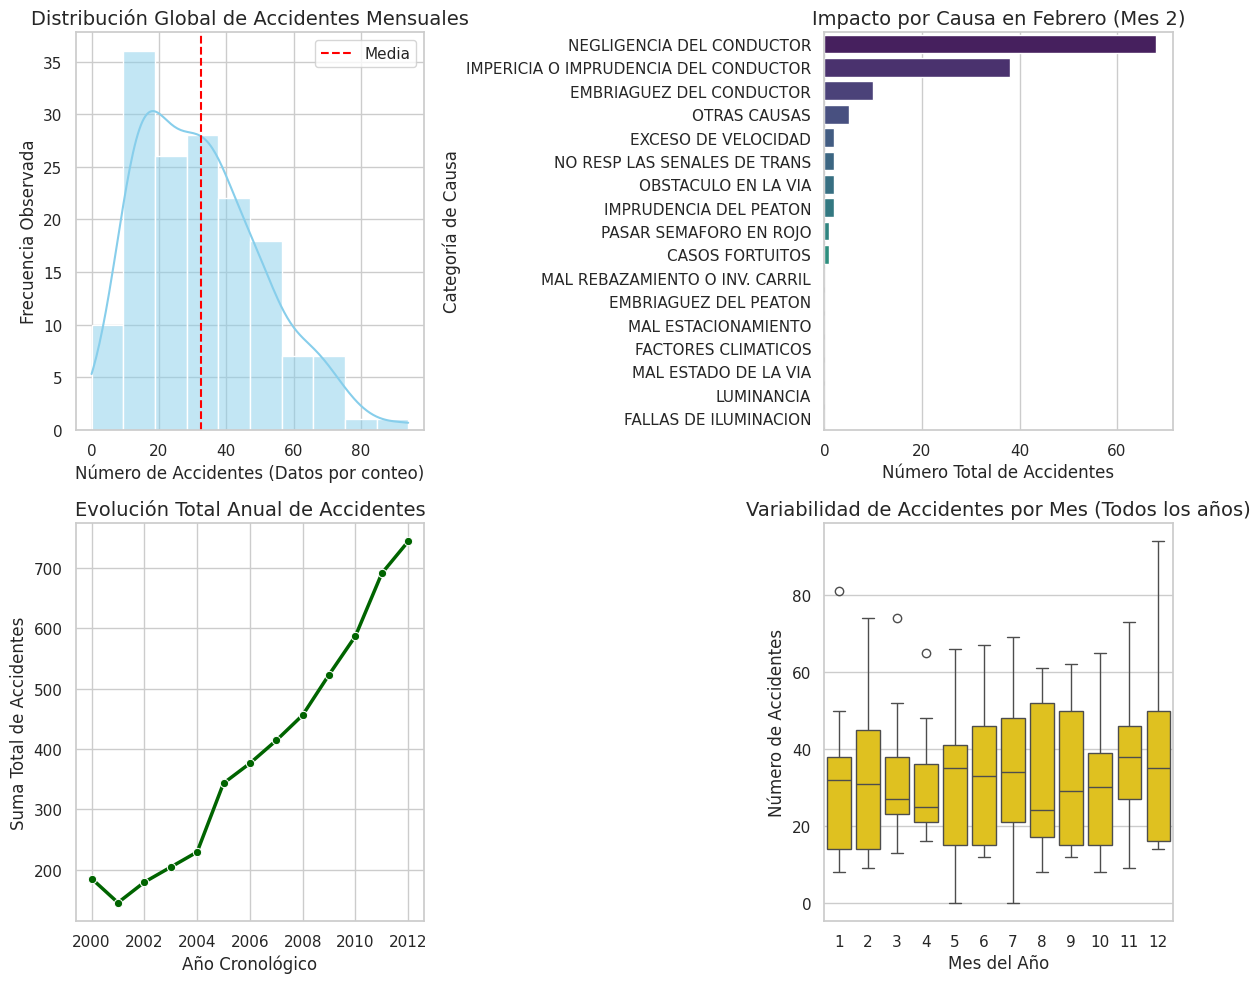

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración estética general
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 10)

# --- GRÁFICA 1: Histograma de Frecuencias (accidentes.csv) ---
plt.subplot(2, 2, 1)
sns.histplot(df_accidentes['numero'], kde=True, color="skyblue")
plt.axvline(df_accidentes['numero'].mean(), color='red', linestyle='--', label='Media')
plt.title('Distribución Global de Accidentes Mensuales', fontsize=14)
plt.xlabel('Número de Accidentes (Datos por conteo)')
plt.ylabel('Frecuencia Observada')
plt.legend()

# --- GRÁFICA 2: Comparativa de Causas en Febrero (Mes 2) ---
# Identifica visualmente los outliers o valores extremos por tipo.
plt.subplot(2, 2, 2)
df_feb = df_causas[df_causas["mes"] == 2].sort_values("numero", ascending=False)
sns.barplot(data=df_feb, x='numero', y='causa', palette="viridis")
plt.title('Impacto por Causa en Febrero (Mes 2)', fontsize=14)
plt.xlabel('Número Total de Accidentes')
plt.ylabel('Categoría de Causa')

# --- GRÁFICA 3: Tendencia Histórica Anual (2000 - 2012) ---
# Útil para observar la variabilidad interanual y evolución del fenómeno.
plt.subplot(2, 2, 3)
df_anual = df_accidentes.groupby('anio')['numero'].sum().reset_index()
sns.lineplot(data=df_anual, x='anio', y='numero', marker='o', color="darkgreen", linewidth=2.5)
plt.title('Evolución Total Anual de Accidentes', fontsize=14)
plt.xlabel('Año Cronológico')
plt.ylabel('Suma Total de Accidentes')

# --- GRÁFICA 4: Diagrama de Caja y Bigotes por Estacionalidad ---
# Resume la mediana, variabilidad y valores extremos.
plt.subplot(2, 2, 4)
sns.boxplot(data=df_accidentes, x='mes', y='numero', color="gold")
plt.title('Variabilidad de Accidentes por Mes (Todos los años)', fontsize=14)
plt.xlabel('Mes del Año')
plt.ylabel('Número de Accidentes')

plt.tight_layout()
plt.show()

--- RESUMEN ESTADÍSTICO REGIONAL ---
Esperanza Matemática E[X] (Promedio esperado): 32.53 accidentes/mes
Varianza Var(X): 32.53 (En Poisson, la varianza es igual a E[X])
Probabilidad de tener un mes 'promedio' (33 accidentes): 6.90%
Probabilidad de alerta roja (45 o más accidentes en un mes): 2.20%


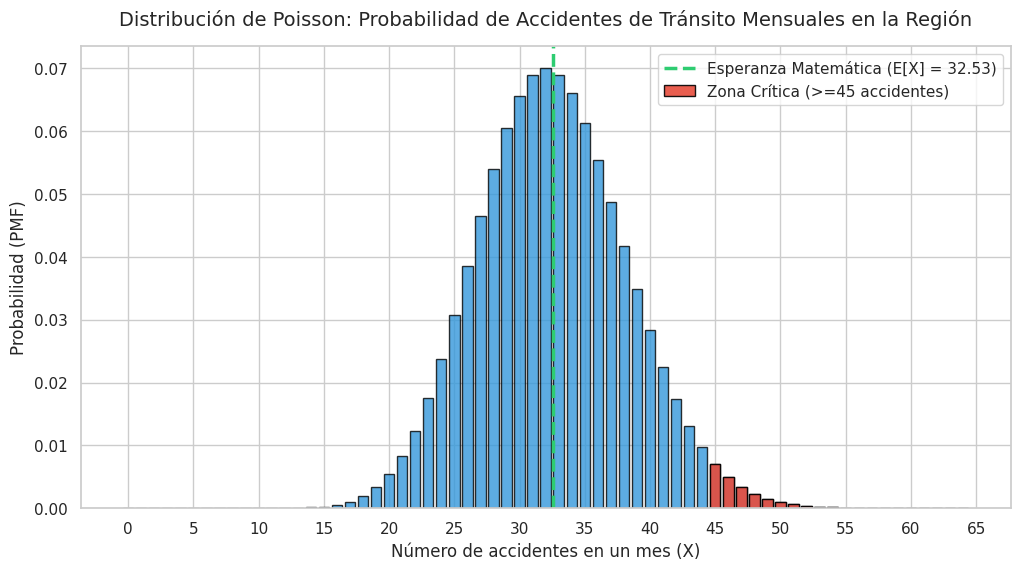

In [ ]:
from scipy.stats import poisson

# Configuración visual
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

# DEFINICIÓN DE LAMBDA
lambda_acc = 32.53

# "Número de accidentes en un mes"
x = np.arange(0, 65)

# Calculamos la PMF para cada valor usando Poisson
pmf_accidentes = poisson.pmf(x, lambda_acc)

# CREACIÓN DE LA GRÁFICA
plt.bar(x, pmf_accidentes, color='#3498db', alpha=0.8, edgecolor='black')

# Resaltar un escenario crítico (Probabilidad de superar los 44 accidentes)
x_critico = np.arange(45, 65)
pmf_critico = poisson.pmf(x_critico, lambda_acc)
plt.bar(x_critico, pmf_critico, color='#e74c3c', alpha=0.9, edgecolor='black', label='Zona Crítica (>=45 accidentes)')

# Líneas y etiquetas para la Esperanza Matemática
plt.axvline(lambda_acc, color='#2ecc71', linestyle='dashed', linewidth=2.5,
            label=f'Esperanza Matemática (E[X] = {lambda_acc})')

plt.title('Distribución de Poisson: Probabilidad de Accidentes de Tránsito Mensuales en la Región', fontsize=14, pad=15)
plt.xlabel('Número de accidentes en un mes (X)', fontsize=12)
plt.ylabel('Probabilidad (PMF)', fontsize=12)

plt.xticks(np.arange(0, 66, 5))
plt.legend(fontsize=11)

# Imprimir cálculos clave para la interpretación
prob_critica = poisson.sf(44, lambda_acc) * 100
prob_exacta = poisson.pmf(33, lambda_acc) * 100

print(f"--- RESUMEN ESTADÍSTICO REGIONAL ---")
print(f"Esperanza Matemática E[X] (Promedio esperado): {lambda_acc} accidentes/mes")
print(f"Varianza Var(X): {lambda_acc} (En Poisson, la varianza es igual a E[X])")
print(f"Probabilidad de tener un mes 'promedio' (33 accidentes): {prob_exacta:.2f}%")
print(f"Probabilidad de alerta roja (45 o más accidentes en un mes): {prob_critica:.2f}%")

plt.show()